# XGB One-Versus-Rest

An alternative way to do classification, where a classifier is fitted for each class.

Based on my notebook, which in turn is based on Chris Deotte's excellent notebook here: https://www.kaggle.com/code/cdeotte/first-place-single-model-lb-38-81

I used GenAI (Claude Sonnet 4.5) for this with the following prompt:

```
[user] This is my best feature set and model - it trains one multiclass XGB model.
        Convert this to one-versus-rest classification with XGB (same XGB params).
        remove pseudo labels
        any questions?

[claude] Model looks solid. One-versus-rest = train 3 binary XGB models (one per class).
    Questions:
    
    Keep same early stopping/eval setup for each binary classifier?
    Keep sample weights + balanced_accuracy metric for binary models?
    For OOF/test - combine 3 binary model probabilities then normalize to [0,1] sum?
    Keep Optuna class weight optimization at end?

[user]
    1. just use log-loss
    2. yes
    3. yes
    4. keep, yes
    
    Also, remember that the submission should in the end be a single class for each row
```

NOTE: `balanced_accuracy` vs log-loss based early-stopping is definitely something to experiment with.

In [1]:
NAME = '001'

In [2]:
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import TargetEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import seaborn as sns

In [3]:
%load_ext cudf.pandas

import numpy as np, pandas as pd, gc
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 200)

In [4]:
train_file = '/kaggle/input/competitions/playground-series-s6e4/train.csv'
test_file = '/kaggle/input/competitions/playground-series-s6e4/test.csv'
original_file = '/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv'

train = pd.read_csv(train_file)
test = pd.read_csv(test_file)
orig = pd.read_csv(original_file)

train_ids = train['id'].copy()
test_ids = test['id'].copy() # for submission

In [5]:
train['Irrigation_Need'] = train['Irrigation_Need'].map(_classes := {'Low': 0, 'Medium': 1, 'High': 2})
orig['Irrigation_Need'] = orig['Irrigation_Need'].map(_classes)

In [6]:
TARGET = 'Irrigation_Need'
NUMS = list(train.drop(['id', TARGET], axis=1)._get_numeric_data().columns)
CATS = [c for c in train.drop(['id', TARGET], axis=1).columns if c not in NUMS]

In [7]:
# simple check
# id + target = 2
assert len(NUMS) + len(CATS) + 2 == train.shape[1]

In [8]:
print(f"There are {len(CATS)} categorical columns:")
print(CATS)
print(f"There are {len(NUMS)} numerical columns:")
print(NUMS)

There are 8 categorical columns:
['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
There are 11 numerical columns:
['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']


# Feature Engineering

In [9]:
NEW_NUMS = []
NEW_CATS = []
NUM_AS_CAT = []
TO_REMOVE = []
NON_TE_CATS = []

In [10]:
_to_combo = CATS

for i, c1 in enumerate(_to_combo[:-1]):
    for j, c2 in enumerate(_to_combo[i + 1:]):
        _new_col = f'COMBO_{c1}_{c2}'

        for df in [train, test, orig]:
            df[_new_col] = df[c1].astype('str') + '_' + df[c2].astype('str')
        NEW_CATS.append(_new_col)

        # 3-combos
        # for k, c3 in enumerate(_to_combo[i+j+2:]):
        #     _new_col = f'COMBO_{c1}_{c2}_{c3}'
        #     for df in [train, test, orig]:
        #         df[_new_col] = df[c1].astype('str') + '_' + df[c2].astype('str') + '_' + df[c3].astype('str')
    
        #     NEW_CATS.append(_new_col)

            # print(c1, c2, c3)
            # 4-combos
            # for l, c4 in enumerate(_to_combo[i+j+k+3:]):
            #     _new_col = f'COMBO_{c1}_{c2}_{c3}_{c4}'
            #     for df in [train, test, orig]:
            #         df[_new_col] = df[c1].astype('str') + '_' + df[c2].astype('str') + '_' + df[c3].astype('str') + '_' + df[c4].astype('str')
        
            #     NEW_CATS.append(_new_col)

In [11]:
# Compute frequencies from ALL data (train + orig + test)
for cat in CATS + NEW_CATS:
    freq = pd.concat([train[cat], orig[cat], test[cat]]).value_counts(normalize=True)
    for df in [train, test, orig]:
        df[f'FREQ_{cat}'] = df[cat].map(freq).fillna(0).astype('float32')
    NEW_NUMS.append(f'FREQ_{cat}')

In [12]:
# numerical as categorical
for col in NUMS:    
    _new_col = f'CAT_{col}'
    NUM_AS_CAT.append(_new_col)

    for df in [train, test, orig]:
        df[_new_col] = df[col].astype(str).astype('category')

In [13]:
# adapted from https://www.kaggle.com/code/yunsuxiaozi/pss6e4-xgb-cv-0-979805

M = train[NUMS].max()
DIGIT_FEATURES = []

for c in NUMS:
    for df in [train, test]:
        for k in range(-4,4):
            df[f"{c}_digit{k}"] = (df[c] // (10**k) % 10).astype('int8')
            DIGIT_FEATURES += [f"{c}_digit{k}"]
    
        if M[c]<10:
            df[c]=df[c].round(3)
        elif M[c]<100:
            df[c]=df[c].round(2)
        else:
            df[c]=df[c].round(1)


DROP=[c for c in test.columns if test[c].nunique()==1]
print(f"DROP:{DROP}")

train.drop(DROP,axis=1,inplace=True)
test.drop(DROP,axis=1,inplace=True)

DIGIT_FEATURES = list(set(DIGIT_FEATURES) - set(DROP))
print()
print('=' * 50)
print("DIGITS: ", DIGIT_FEATURES)
NEW_CATS += DIGIT_FEATURES

DROP:['Soil_pH_digit1', 'Soil_pH_digit2', 'Soil_pH_digit3', 'Soil_Moisture_digit2', 'Soil_Moisture_digit3', 'Organic_Carbon_digit1', 'Organic_Carbon_digit2', 'Organic_Carbon_digit3', 'Electrical_Conductivity_digit1', 'Electrical_Conductivity_digit2', 'Electrical_Conductivity_digit3', 'Temperature_C_digit2', 'Temperature_C_digit3', 'Humidity_digit2', 'Humidity_digit3', 'Sunlight_Hours_digit2', 'Sunlight_Hours_digit3', 'Wind_Speed_kmh_digit2', 'Wind_Speed_kmh_digit3', 'Field_Area_hectare_digit2', 'Field_Area_hectare_digit3', 'Previous_Irrigation_mm_digit3']

DIGITS:  ['Soil_Moisture_digit1', 'Wind_Speed_kmh_digit-3', 'Soil_Moisture_digit-1', 'Rainfall_mm_digit0', 'Soil_pH_digit0', 'Soil_Moisture_digit-2', 'Wind_Speed_kmh_digit-1', 'Temperature_C_digit1', 'Field_Area_hectare_digit-2', 'Sunlight_Hours_digit-2', 'Field_Area_hectare_digit1', 'Previous_Irrigation_mm_digit1', 'Rainfall_mm_digit1', 'Wind_Speed_kmh_digit-2', 'Rainfall_mm_digit-3', 'Electrical_Conductivity_digit-1', 'Field_Area_h

see https://www.kaggle.com/code/cdeotte/original-data-exact-formula for exact formula for `orig`

In [14]:
for df in [train, test]:
    # 4 boolean numeric features based on threshold insights
    df["soil_lt_25"] = (df["Soil_Moisture"] < 25).astype(int)
    df["temp_gt_30"] = (df["Temperature_C"] > 30).astype(int)
    df["rain_lt_300"] = (df["Rainfall_mm"] < 300).astype(int)
    df["wind_gt_10"] = (df["Wind_Speed_kmh"] > 10).astype(int)


TRES_CATS = ['soil_lt_25', 'temp_gt_30', 'rain_lt_300', 'wind_gt_10']
NEW_CATS += TRES_CATS

In [15]:
for df_ in [train, test]:
    df = pd.get_dummies(
        df_[NUMS + CATS + TRES_CATS],
        columns=CATS,
        drop_first=False
    )

    df_['logit(P(y=Low))'] = 16.3173 + (-11.0237 * df["soil_lt_25"]) + (-5.8559 * df["temp_gt_30"]) + (-10.8500 * df["rain_lt_300"]) + (-5.8284 * df["wind_gt_10"]) + (-5.4155 * df["Crop_Growth_Stage_Flowering"]) + (5.5073 * df["Crop_Growth_Stage_Harvest"]) + (5.2299 * df["Crop_Growth_Stage_Sowing"]) + (-5.4617 * df["Crop_Growth_Stage_Vegetative"]) + (-3.0014 * df["Mulching_Used_No"]) + (2.8613 * df["Mulching_Used_Yes"])
    df_['logit(P(y=Medium))'] = 4.6524 + (0.3290 * df["soil_lt_25"]) + (-0.0204 * df["temp_gt_30"]) + (0.1542 * df["rain_lt_300"]) + (0.0841 * df["wind_gt_10"]) + (0.3586 * df["Crop_Growth_Stage_Flowering"]) + (-0.1348 * df["Crop_Growth_Stage_Harvest"]) + (-0.3547 * df["Crop_Growth_Stage_Sowing"]) + (0.3334 * df["Crop_Growth_Stage_Vegetative"]) + (0.1883 * df["Mulching_Used_No"]) + (0.0142 * df["Mulching_Used_Yes"])
    df_['logit(P(y=High))'] = -20.9697 + (10.6947 * df["soil_lt_25"]) + (5.8763 * df["temp_gt_30"]) + (10.6958 * df["rain_lt_300"]) + (5.7444 * df["wind_gt_10"]) + (5.0569 * df["Crop_Growth_Stage_Flowering"]) + (-5.3725 * df["Crop_Growth_Stage_Harvest"]) + (-4.8752 * df["Crop_Growth_Stage_Sowing"]) + (5.1283 * df["Crop_Growth_Stage_Vegetative"]) + (2.8131 * df["Mulching_Used_No"]) + (-2.8755 * df["Mulching_Used_Yes"])

NEW_NUMS += ['logit(P(y=Low))', 'logit(P(y=Medium))', 'logit(P(y=High))']

In [16]:
train.isna().any().any(), test.isna().any().any()

(np.False_, np.False_)

In [17]:
for col in CATS + NUMS:
    stats = orig.groupby(col)[TARGET].agg(['mean', 'std']).reset_index()
    stats.columns = [col] + [f"ORIG_{col}_{s}" for s in ['mean', 'std']]

    train = train.merge(stats, on=col, how='left')
    test = test.merge(stats, on=col, how='left')

    fill_values = {
        f"ORIG_{col}_mean": 0.5,
        f"ORIG_{col}_std": 0,
    }
    train = train.fillna(value=fill_values)
    test = test.fillna(value=fill_values)

    NEW_NUMS.extend([f"ORIG_{col}_{s}" for s in ['mean', 'std']])

In [18]:
FEATURES = NUMS + CATS + NEW_NUMS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS
print(f'We now have {len(FEATURES)} columns:')
print(FEATURES)

We now have 205 columns:
['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm', 'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'FREQ_Soil_Type', 'FREQ_Crop_Type', 'FREQ_Crop_Growth_Stage', 'FREQ_Season', 'FREQ_Irrigation_Type', 'FREQ_Water_Source', 'FREQ_Mulching_Used', 'FREQ_Region', 'FREQ_COMBO_Soil_Type_Crop_Type', 'FREQ_COMBO_Soil_Type_Crop_Growth_Stage', 'FREQ_COMBO_Soil_Type_Season', 'FREQ_COMBO_Soil_Type_Irrigation_Type', 'FREQ_COMBO_Soil_Type_Water_Source', 'FREQ_COMBO_Soil_Type_Mulching_Used', 'FREQ_COMBO_Soil_Type_Region', 'FREQ_COMBO_Crop_Type_Crop_Growth_Stage', 'FREQ_COMBO_Crop_Type_Season', 'FREQ_COMBO_Crop_Type_Irrigation_Type', 'FREQ_COMBO_Crop_Type_Water_Source', 'FREQ_COMBO_Crop_Type_Mulching_Used', 'FREQ_COMBO_Crop_Type_Region', 'FREQ_COMBO_Crop_Growth

In [19]:
TE_COLUMNS = NUM_AS_CAT + CATS + NEW_CATS
TO_REMOVE += NUM_AS_CAT + CATS + NEW_CATS
QUANTILE_COLUMNS = []

# Model Training

In [20]:
np.random.seed(11)

In [21]:
FOLDS = 5
INNER_FOLDS = 5

In [22]:
xgb_params = {
    'n_estimators': 50000,
    'max_depth': 4,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'learning_rate': 0.1,
    'n_jobs': -1,
    'enable_categorical': True,
    'alpha': 5,
    'reg_lambda': 5,
    'max_leaves': 30,
    'min_child_weight': 2,
    'tree_method': 'hist',
    'max_bin': 10000,
    'device':'cuda',
    'objective': 'binary:logistic',  # binary for OVR
}

# TE

In [23]:
from functools import reduce

class OrderedTE:
    def __init__(self, a=1):
        self.a = a

    def fit(self, train, category_cols=(), target_col='target'):
        self.category_cols = category_cols
        self.classes_ = sorted(train[target_col].unique())
        self.global_prior_ = train[target_col].value_counts(normalize=True).sort_index().values
        self.stats_ = {}

        for c in category_cols:
            stats_list = []
            for k, cls in enumerate(self.classes_):
                y = (train[target_col] == cls).astype(int)
                grp = train[[c]].assign(y=y.values)

                cum_cnt = grp.groupby(c, observed=False)['y'].cumcount()
                cum_sum = grp.groupby(c, observed=False)['y'].cumsum() - grp['y']

                prior = self.global_prior_[k]
                te = (cum_sum + self.a * prior) / (cum_cnt + self.a)
                te_col = f'{c}_TE_cls{cls}'
                train[te_col] = te.values

                agg = grp.groupby(c, observed=False)['y'].agg(count='count', total='sum').reset_index()
                agg.columns = [c, f'{c}_n_{cls}', f'{c}_s_{cls}']
                stats_list.append(agg)

            self.stats_[c] = reduce(lambda l, r: l.merge(r, on=c, how='outer'), stats_list)

        return train

    def transform(self, test):
        for c in self.category_cols:
            test = test.merge(self.stats_[c], on=c, how='left')

            for k, cls in enumerate(self.classes_):
                te_col = f'{c}_TE_cls{cls}'
                n_col, s_col = f'{c}_n_{cls}', f'{c}_s_{cls}'
                prior = self.global_prior_[k]

                if n_col in test.columns:
                    test[te_col] = ((test[s_col] + self.a * prior) / (test[n_col] + self.a)).fillna(prior)
                    test.drop(columns=[n_col, s_col], inplace=True)
                else:
                    test[te_col] = prior

        return test

# Model Training

In [24]:
def metric(y_true, y_pred, sample_weight=None):
    y_pred = np.argmax(y_pred, axis=1)
    return balanced_accuracy_score(y_true, y_pred, sample_weight=sample_weight)

In [25]:
# %%time

print(f"\n{'='*80}")
print("TRAINING XGBOOST ONE-VERSUS-REST")
print("="*80)

kf = KFold(n_splits=FOLDS, shuffle=True, random_state=11)

# Store probabilities for each class
oof = np.zeros((len(train), 3))
pred = np.zeros((len(test), 3))
importances = {0: [], 1: [], 2: []}
metric_folds = []

for i, (train_index, val_index) in enumerate(kf.split(train)):
    print(f"\n{'='*60}")
    print(f"Fold {i+1}/{FOLDS}")
    print('='*60)

    # ===================================
    # TRAIN/VAL SPLIT
    # ===================================
    X_train = train.loc[train_index,FEATURES+[TARGET]].reset_index(drop=True).copy()
    y_train_multiclass = train.loc[train_index, TARGET]
    
    X_val = train.loc[val_index,FEATURES].reset_index(drop=True).copy()
    y_val_multiclass = train.loc[val_index,TARGET]

    X_train = pd.concat([X_train],axis=0).reset_index(drop=True).copy()
    y_train_multiclass = np.concatenate([y_train_multiclass],axis=0).copy()
    
    X_test = test[FEATURES].reset_index(drop=True).copy()
    
    # ===================================
    # Target encoding
    # ===================================
    target_encoder = OrderedTE(a=1)
    X_train = target_encoder.fit(X_train, category_cols=TE_COLUMNS, target_col=TARGET)
    X_val = target_encoder.transform(X_val)
    X_test = target_encoder.transform(X_test)
    
    # ===================================    
    # CONVERT TO CATS SO XGBOOST RECOGNIZES THEM
    X_train[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS] = X_train[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS].astype(str).astype("category")
    X_val[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS] = X_val[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS].astype(str).astype("category")
    X_test[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS] = X_test[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS].astype(str).astype("category")

    X_train.drop(TO_REMOVE, axis=1, inplace=True)
    X_val.drop(TO_REMOVE, axis=1, inplace=True)
    X_test.drop(TO_REMOVE, axis=1, inplace=True)

    # DROP TARGET THAT WAS USED FOR TARGET ENCODING
    X_train = X_train.drop([TARGET],axis=1)
    COLS = X_train.columns
    
    # ===================================
    # Train 3 binary OVR models
    # ===================================
    fold_oof_probs = np.zeros((len(X_val), 3))
    fold_test_probs = np.zeros((len(X_test), 3))
    
    for class_idx in range(3):
        print(f"\n  Training binary classifier for class {class_idx}")
        
        # Create binary target: 1 if this class, 0 otherwise
        y_train_binary = (y_train_multiclass == class_idx).astype(int)
        y_val_binary = (y_val_multiclass == class_idx).astype(int)
        
        # Compute sample weights for balanced training
        s_wei_train = compute_sample_weight('balanced', y_train_binary)
        
        # Train binary XGB classifier
        model = xgb.XGBClassifier(
            **xgb_params,
            eval_metric='logloss',
            callbacks=[
              xgb.callback.EarlyStopping(
                  rounds=500, metric_name='logloss',
                  save_best=True
              )
            ],
        )
        model.fit(
            X_train, y_train_binary,
            sample_weight=s_wei_train,
            eval_set=[(X_val, y_val_binary)],
            verbose=1000
        )
        
        # Get probability of positive class (this class)
        fold_oof_probs[:, class_idx] = model.predict_proba(X_val)[:, 1]
        fold_test_probs[:, class_idx] = model.predict_proba(X_test[COLS])[:, 1]
        
        # Store importances
        importances[class_idx].append(model.get_booster().get_score(importance_type='gain'))
    
    # Normalize probabilities to sum to 1
    fold_oof_probs = fold_oof_probs / fold_oof_probs.sum(axis=1, keepdims=True)
    fold_test_probs = fold_test_probs / fold_test_probs.sum(axis=1, keepdims=True)
    
    # Store in global arrays
    oof[val_index] = fold_oof_probs
    pred += fold_test_probs
    
    # Calculate balanced accuracy for this fold
    bal_acc_fold = metric(y_val_multiclass, fold_oof_probs)
    metric_folds.append(bal_acc_fold)
    print(f"\nFold {i+1} Validation Balanced Accuracy: {bal_acc_fold:.5f}")
    
    # CLEAR MEMORY
    del X_train, X_val, X_test
    del y_train_multiclass, y_val_multiclass
    gc.collect()

pred /= FOLDS


TRAINING XGBOOST ONE-VERSUS-REST

Fold 1/5

  Training binary classifier for class 0
[0]	validation_0-logloss:0.60231
[1000]	validation_0-logloss:0.03783
[1075]	validation_0-logloss:0.03786

  Training binary classifier for class 1
[0]	validation_0-logloss:0.60386
[1000]	validation_0-logloss:0.04935
[1600]	validation_0-logloss:0.04956

  Training binary classifier for class 2
[0]	validation_0-logloss:0.60419
[1000]	validation_0-logloss:0.01314
[2000]	validation_0-logloss:0.01272
[2231]	validation_0-logloss:0.01278

Fold 1 Validation Balanced Accuracy: 0.97266

Fold 2/5

  Training binary classifier for class 0
[0]	validation_0-logloss:0.60244
[877]	validation_0-logloss:0.04010

  Training binary classifier for class 1
[0]	validation_0-logloss:0.60394
[1000]	validation_0-logloss:0.04992
[1553]	validation_0-logloss:0.04992

  Training binary classifier for class 2
[0]	validation_0-logloss:0.60443
[1000]	validation_0-logloss:0.01163
[2000]	validation_0-logloss:0.01096
[2107]	validation_0

In [26]:
print(f'Fold Balanced Accuracy {np.mean(metric_folds):.5f} +- {np.std(metric_folds):.5f}')

true = train[TARGET].values
print(f'Overall Balanced Accuracy: {metric(true, oof)}')

Fold Balanced Accuracy 0.97382 +- 0.00079
Overall Balanced Accuracy: 0.9738255427032941


In [27]:
print(f'\nIn total, we used {len(COLS)} features, Wow!\n')
print(list(COLS))


In total, we used 439 features, Wow!

['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm', 'FREQ_Soil_Type', 'FREQ_Crop_Type', 'FREQ_Crop_Growth_Stage', 'FREQ_Season', 'FREQ_Irrigation_Type', 'FREQ_Water_Source', 'FREQ_Mulching_Used', 'FREQ_Region', 'FREQ_COMBO_Soil_Type_Crop_Type', 'FREQ_COMBO_Soil_Type_Crop_Growth_Stage', 'FREQ_COMBO_Soil_Type_Season', 'FREQ_COMBO_Soil_Type_Irrigation_Type', 'FREQ_COMBO_Soil_Type_Water_Source', 'FREQ_COMBO_Soil_Type_Mulching_Used', 'FREQ_COMBO_Soil_Type_Region', 'FREQ_COMBO_Crop_Type_Crop_Growth_Stage', 'FREQ_COMBO_Crop_Type_Season', 'FREQ_COMBO_Crop_Type_Irrigation_Type', 'FREQ_COMBO_Crop_Type_Water_Source', 'FREQ_COMBO_Crop_Type_Mulching_Used', 'FREQ_COMBO_Crop_Type_Region', 'FREQ_COMBO_Crop_Growth_Stage_Season', 'FREQ_COMBO_Crop_Growth_Stage_Irrigation_Type', 'FREQ_COMBO_Crop_Growth_Stage_Water_Sourc

# XGB Feature Importance (per class)

In [28]:
# Average importance across all classes and folds
all_importances = []
for class_idx in range(3):
    for fold_imp in importances[class_idx]:
        all_importances.append(fold_imp)

feature_names = all_importances[0].keys()
importances_mean = [
    np.mean([imp[feat] if feat in imp else 0 for imp in all_importances])
    for feat in feature_names
]

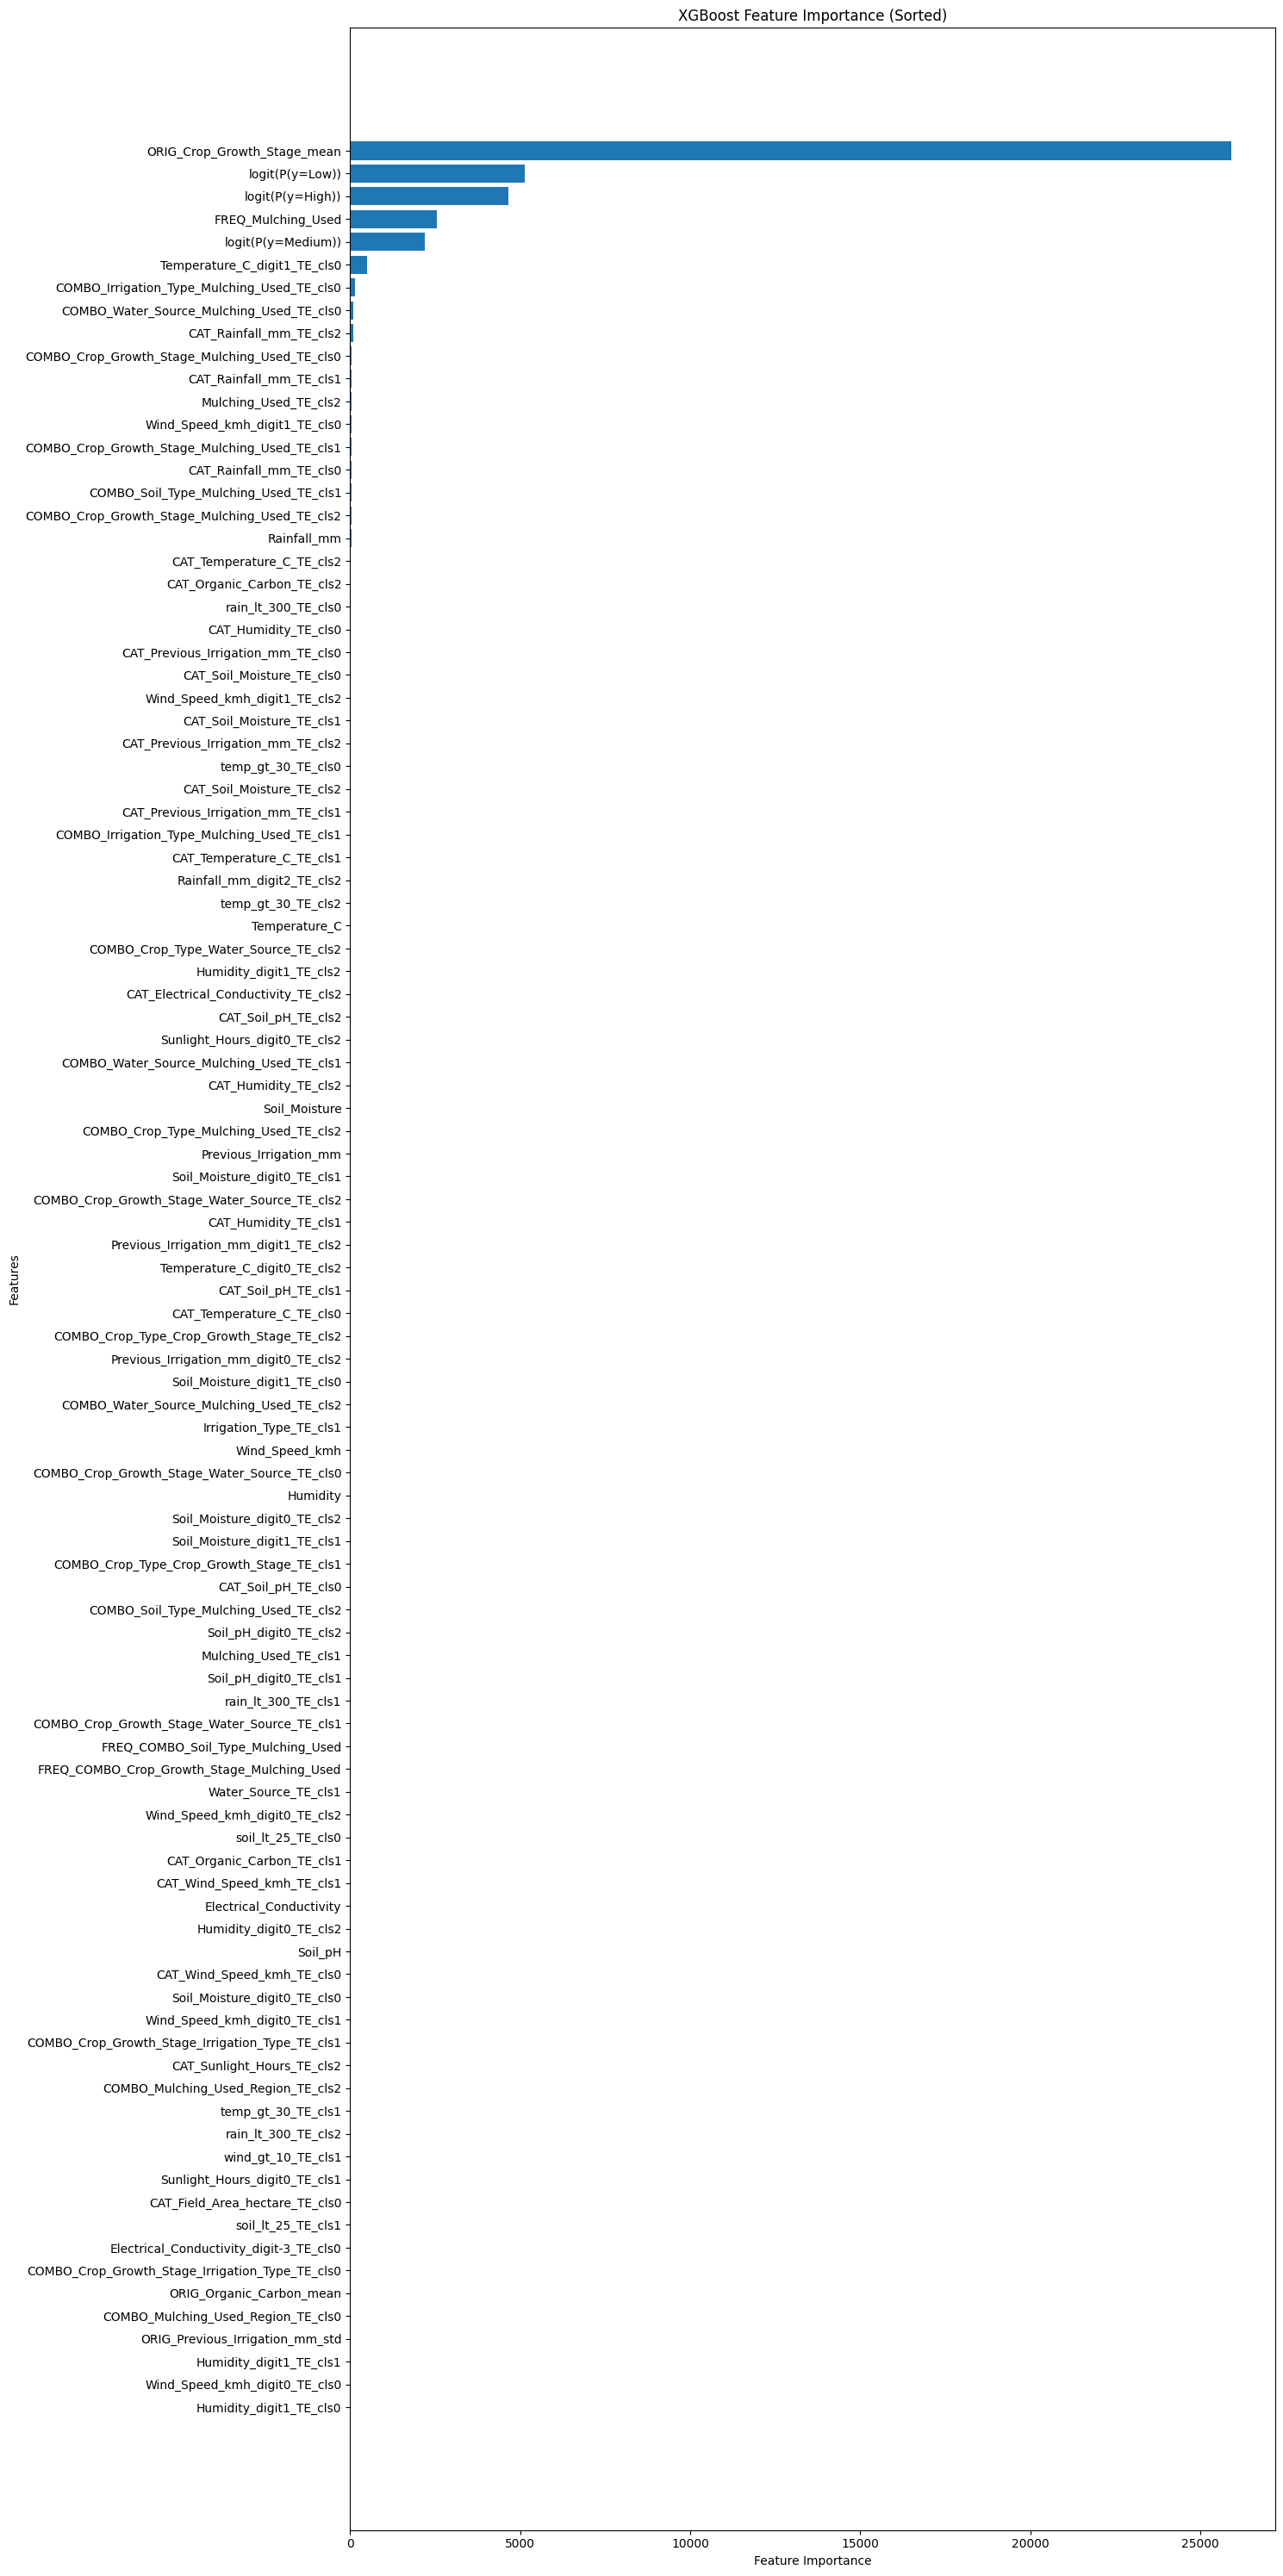

In [29]:
indices = np.argsort(importances_mean)
sorted_features = np.array(list(feature_names))[indices][-100:]
sorted_importance = np.array(importances_mean)[indices][-100:]

# Plot horizontally (features on y-axis for better readability)
plt.figure(figsize=(15, 30))
plt.barh(range(len(sorted_importance)), sorted_importance)
plt.yticks(range(len(sorted_features)), sorted_features)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('XGBoost Feature Importance (Sorted)')
plt.tight_layout()
plt.show()

In [30]:
dict(sorted(zip(feature_names, [float(f) for f in importances_mean]), key=lambda x: -x[1]))

{'ORIG_Crop_Growth_Stage_mean': 25905.05863275528,
 'logit(P(y=Low))': 5142.899161783854,
 'logit(P(y=High))': 4652.865348307291,
 'FREQ_Mulching_Used': 2541.861751302083,
 'logit(P(y=Medium))': 2206.825390625,
 'Temperature_C_digit1_TE_cls0': 501.63857116699216,
 'COMBO_Irrigation_Type_Mulching_Used_TE_cls0': 147.22941004435222,
 'COMBO_Water_Source_Mulching_Used_TE_cls0': 98.09091946283976,
 'CAT_Rainfall_mm_TE_cls2': 84.718377049764,
 'COMBO_Crop_Growth_Stage_Mulching_Used_TE_cls0': 48.91674690246582,
 'CAT_Rainfall_mm_TE_cls1': 46.417930857340494,
 'Mulching_Used_TE_cls2': 46.261481825510664,
 'Wind_Speed_kmh_digit1_TE_cls0': 44.2162304520607,
 'COMBO_Crop_Growth_Stage_Mulching_Used_TE_cls1': 41.15405960083008,
 'CAT_Rainfall_mm_TE_cls0': 39.72286078135173,
 'COMBO_Soil_Type_Mulching_Used_TE_cls1': 38.32184232076009,
 'COMBO_Crop_Growth_Stage_Mulching_Used_TE_cls2': 35.5220339457194,
 'Rainfall_mm': 33.50558993021647,
 'CAT_Temperature_C_TE_cls2': 28.894393984476725,
 'CAT_Organic_

In [31]:
def accuracy_score(t,p):
    if len(p.shape)==2:
        p=np.argmax(p,axis=1)
    C=3
    acc=0.0
    for i in range(C):
        acc+=np.sum((t==i)&(p==i))/np.sum(t==i)/C
    return acc      

In [32]:
# see https://www.kaggle.com/code/yunsuxiaozi/pss6e4-xgb-cv-0-979805
oof_preds = oof
y = train[TARGET]

import optuna
from optuna.samplers import TPESampler

def objective(trial):
    cw1 = trial.suggest_float('cw1', 0.5, 3.0)
    cw2 = trial.suggest_float('cw2', 0.5, 3.0)
    cw3 = trial.suggest_float('cw3', 0.5, 3.0)
    
    class_weights = np.array([cw1, cw2, cw3])
    adjusted_probs = oof_preds * class_weights
    
    adjusted_probs = adjusted_probs / adjusted_probs.sum(axis=1, keepdims=True)
    acc = accuracy_score(y, np.argmax(adjusted_probs, axis=1))
    
    return acc

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='class_weight_optimization'
)

[I 2026-04-21 15:01:43,268] A new study created in memory with name: class_weight_optimization


In [33]:
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"Best oof acc: {study.best_value:.6f}")
print(f"  class_0 = {study.best_params['cw1']:.4f}")
print(f"  class_1 = {study.best_params['cw2']:.4f}")
print(f"  class_2 = {study.best_params['cw3']:.4f}")

best_cw = np.array([study.best_params['cw1'], 
                    study.best_params['cw2'], 
                    study.best_params['cw3']])

final_oof_probs = oof * best_cw
final_oof_probs = final_oof_probs / final_oof_probs.sum(axis=1, keepdims=True)

final_test_probs = pred * best_cw
final_test_probs = final_test_probs / final_test_probs.sum(axis=1, keepdims=True)

final_test_preds = np.argmax(final_test_probs, axis=1)

  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-04-21 15:01:43,375] Trial 0 finished with value: 0.9717749482148288 and parameters: {'cw1': 1.4363502971184063, 'cw2': 2.87678576602479, 'cw3': 2.3299848545285125}. Best is trial 0 with value: 0.9717749482148288.
[I 2026-04-21 15:01:43,433] Trial 1 finished with value: 0.9736289765661356 and parameters: {'cw1': 1.9966462104925915, 'cw2': 0.8900466011060912, 'cw3': 0.8899863008405067}. Best is trial 1 with value: 0.9736289765661356.
[I 2026-04-21 15:01:43,494] Trial 2 finished with value: 0.9694212520982874 and parameters: {'cw1': 0.6452090304204987, 'cw2': 2.665440364437338, 'cw3': 2.002787529358022}. Best is trial 1 with value: 0.9736289765661356.
[I 2026-04-21 15:01:43,552] Trial 3 finished with value: 0.9783770137646497 and parameters: {'cw1': 2.2701814444901136, 'cw2': 0.5514612357395061, 'cw3': 2.9247746304049858}. Best is trial 3 with value: 0.9783770137646497.
[I 2026-04-21 15:01:43,612] Trial 4 finished with value: 0.9729230473025106 and parameters: {'cw1': 2.5811066020

In [34]:
print(f"Best oof acc: {study.best_value:.6f}")
print(f"  class_0 = {study.best_params['cw1']:.4f}")
print(f"  class_1 = {study.best_params['cw2']:.4f}")
print(f"  class_2 = {study.best_params['cw3']:.4f}")

Best oof acc: 0.978862
  class_0 = 0.5125
  class_1 = 0.5403
  class_2 = 2.7975


In [35]:
print(f'Overall Balanced Accuracy: {metric(true, final_oof_probs)}')

Overall Balanced Accuracy: 0.978861743093244


# Save CSV

In [36]:
# SAVE OOF TO DISK FOR ENSEMBLES
df_oof = pd.DataFrame({'xgb': final_oof_probs.flatten()})
df_oof.to_csv(f'{NAME}_oof.csv', index=False)

df_test = pd.DataFrame({'xgb': final_test_probs.flatten()})
df_test.to_csv(f'{NAME}_test.csv', index=False)

print("Saved oof and test predictions to file")

Saved oof and test predictions to file


In [37]:
test.shape

(270000, 206)

In [38]:
sub = pd.DataFrame({
    'id': test_ids,
    # TARGET: np.argmax(pred, axis=1)
    TARGET: final_test_preds
})
sub[TARGET] = sub[TARGET].map({0: 'Low', 1: 'Medium', 2: 'High'})

sub.to_csv(f'{NAME}_submission.csv', index=False)
sub

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
...,...,...
269995,899995,Medium
269996,899996,Low
269997,899997,Medium
269998,899998,Low
